In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import re

__The Problem: Sensor Anomaly Detection & Time-Series Analysis__
This one steps into territory you haven't touched yet: time-series resampling, rolling windows, and detecting anomalies. It's the kind of analysis you'd do on IoT sensor data, server metrics, or anything that emits a measurement on a schedule.
You'll work with synthetic data from a fleet of industrial sensors. Two files:
sensors.csv — sensor_id, install_date, location, model, firmware_version
readings.csv — sensor_id, timestamp, temperature, pressure, vibration, status

Readings are roughly every 15 minutes, but with realistic gaps (sensors go offline, miss intervals, get rebooted)
status is one of ok, warning, error, offline
The data has anomalies baked in: sudden spikes, gradual drift, sensor failures, and correlated failures across nearby sensors

1. Data hygiene & gaps. Load both files. Parse timestamps. For each sensor, compute the longest gap between consecutive readings. Which sensors have suspicious gaps (> 1 hour)? What fraction of expected readings are missing per sensor, assuming a 15-minute cadence?

In [5]:
sensor_dat = pd.read_csv('./data/sensors.csv')

print("Loading Sensor Data")
sensor_dat['Install Date'] = sensor_dat['Install Date'].apply(pd.to_datetime)
sensor_dat.rename(columns={'Install Date':'install_date'}, inplace=True)

print("Loading Readings Data")
readings_dat = pd.read_csv('./data/readings.csv')
readings_dat.rename(columns={'Sensor ID':'sensor_id','Timestamp':'timestamp','Pressure (kPa)':'pressure_kpa','STATUS':'status', 'temp_C':'temp_c'}, inplace=True)

def parse_mixed_timestamps(d):
    datetime_regex = [ \
        (r"^\d{4}-\d{2}-\d{2}\s\d{2}:\d{2}:\d{2}[+-]\d{2}:\d{2}$", "%Y-%m-%d %H:%M:%S%z"),
        (r"^\d{4}-\d{2}-\d{2}\s\d{2}:\d{2}:\d{2}$", "%Y-%m-%d %H:%M:%S"),
        (r"^\d{2}-\d{2}-\d{4}\s\d{2}:\d{2}:\d{2}$", "%d-%m-%Y %H:%M:%S"),
        (r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}$",  "%Y-%m-%dT%H:%M:%S"),
        (r"^\d{2}/\d{2}/\d{4} \d{2}:\d{2}:\d{2}$",  "%m/%d/%Y %H:%M:%S")
        ]

    try:
        for fmt in datetime_regex:
            match = re.search(fmt[0], d)
            if match != None:    
                return dt.datetime.strptime(d, fmt[1])
    except ValueError:
        return d

print("...Fixing Mixed Timestamps")
readings_dat.timestamp = readings_dat.timestamp.apply(lambda l: parse_mixed_timestamps(l))
readings_dat.timestamp = pd.to_datetime(readings_dat.timestamp, utc=True)

# Clean Status Column
print("...Cleaning Status Column")
readings_dat['status'] = readings_dat.status.apply(lambda x: x.strip().lower())

print("...Fixing pressure readings")
readings_dat.pressure_kpa = readings_dat.pressure_kpa.replace('\\D+$', 0, regex = True).astype('float')

#Drop Duplicates
print(f"...Removing {readings_dat.duplicated().sum()} duplicated readings")
readings_dat.drop_duplicates(inplace=True)

readings_dat = pd.merge(readings_dat.groupby('sensor_id').agg(first_reading=('timestamp','min'), \
                                     latest_reading=('timestamp','max')),
                        readings_dat, on='sensor_id')

#Adding Location
readings_dat = pd.merge(readings_dat, sensor_dat[['Location','sensor_id']], on='sensor_id')
readings_dat.rename(columns={'Location':'location'}, inplace=True)

readings_dat.head()


Loading Sensor Data
Loading Readings Data
...Fixing Mixed Timestamps
...Cleaning Status Column
...Fixing pressure readings
...Removing 6 duplicated readings


,sensor_id,first_reading,latest_reading,timestamp,temp_c,pressure_kpa,vibration_mm_s,status,location
0,SEN-001,2025-01-01 00:00:53+00:00,2025-01-14 23:45:10+00:00,2025-01-02 17:01:17+00:00,64.20,104.12,0.5914,ok,Plant_A_North
1,SEN-001,2025-01-01 00:00:53+00:00,2025-01-14 23:45:10+00:00,2025-01-12 08:15:55+00:00,64.66,102.65,0.4815,ok,Plant_A_North
2,SEN-001,2025-01-01 00:00:53+00:00,2025-01-14 23:45:10+00:00,2025-01-10 04:16:09+00:00,61.55,102.23,0.4744,ok,Plant_A_North
3,SEN-001,2025-01-01 00:00:53+00:00,2025-01-14 23:45:10+00:00,2025-01-14 02:43:30+00:00,60.87,102.31,0.5324,ok,Plant_A_North
4,SEN-001,2025-01-01 00:00:53+00:00,2025-01-14 23:45:10+00:00,2025-01-01 03:16:21+00:00,61.56,102.64,0.5855,ok,Plant_A_North


Preliminary Analysis ....
.. There are 220 missing data points


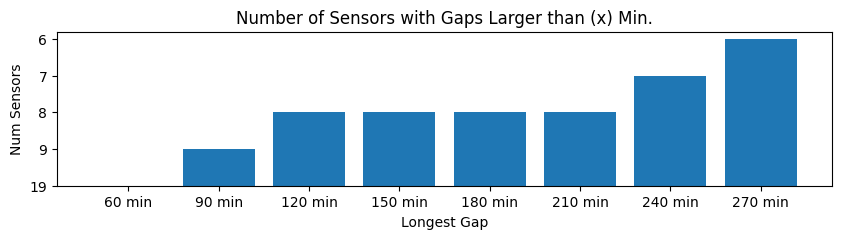

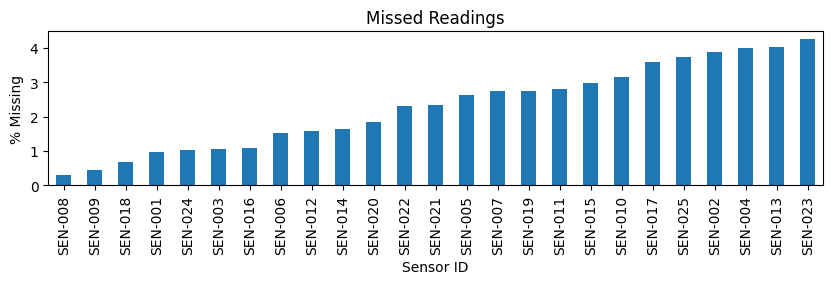

In [6]:
print('Preliminary Analysis ....')
readings_dat[readings_dat.isna().any(axis=1)]
readings_dat.isnull().values.sum()
print(f'.. There are {readings_dat.isnull().values.sum()} missing data points')

readings_dat['time_since_last_reading'] = readings_dat.sort_values('timestamp'). \
    groupby('sensor_id').timestamp.diff()

gap_matrix = []
for i in range(2,10):
    gap_threshold = str(30 * i) + ' min'
    gap_matrix.append((gap_threshold, readings_dat[readings_dat.time_since_last_reading > gap_threshold].sensor_id.nunique()))
    # print(f"There are {readings_dat[readings_dat.time_since_last_reading > gap_threshold].sensor_id.nunique()} sensors with gaps larger than {gap_threshold}")
    # a 90min gap seems indicitive of suspicious activity

gap_matrix = np.array(gap_matrix)
plt.figure(1, figsize=(10,2))
plt.bar(gap_matrix[:, 0], gap_matrix[:, 1])
plt.xlabel('Longest Gap')
plt.ylabel('Num Sensors')
plt.title('Number of Sensors with Gaps Larger than (x) Min.')


expected_readings = (readings_dat.groupby('sensor_id').latest_reading.max() - readings_dat.groupby('sensor_id').first_reading.max()).dt.total_seconds() / 60 / 15

actual_readings = readings_dat.groupby('sensor_id').timestamp.count()
fraction_missing = (expected_readings - actual_readings) / (expected_readings + actual_readings) / 2 * 100
plt.figure(2, figsize=(10,2))
fraction_missing.sort_values().plot(kind='bar', title='Missed Readings', xlabel='Sensor ID', ylabel='% Missing')
display()


2. Resample to regular intervals. Sensor readings don't arrive on exact 15-minute boundaries. Resample each sensor's data to a clean 15-minute grid, taking the mean of any readings in each bucket and forward-filling small gaps (≤ 2 buckets) but leaving longer gaps as NaN. Hint: this is per-sensor, so groupby + resample, or a loop.

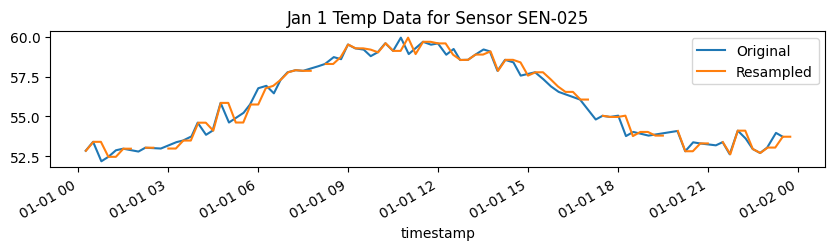

In [7]:
resampled_readings = readings_dat \
    .sort_values('timestamp') \
    .set_index('timestamp') \
    .groupby('sensor_id') \
    [['temp_c', 'pressure_kpa', 'vibration_mm_s']] \
    .resample('15min').ffill(limit=2)

sensor = 'SEN-025'
plt.figure(figsize=(10,2))
readings_dat.sort_values('timestamp').set_index(['sensor_id','timestamp']).loc[sensor].loc['2025-01-1'].temp_c.dropna().plot(label='Original')
resampled_readings.loc[sensor].loc['2025-01-1'].temp_c.plot(label='Resampled')
plt.title(f'Jan 1 Temp Data for Sensor {sensor}')

plt.legend()
plt.show()

3. Rolling baseline & z-score anomalies. For each sensor, compute a 24-hour rolling mean and rolling standard deviation of temperature. Flag any reading where temperature is more than 3 standard deviations from the rolling mean as an anomaly. How many anomalies per sensor? Per location? Are anomalies clustered in time?

Anomalies are when a reading exceeds the the boundary of 3 STD above/below the Rolling 24hour Mean
Anomalies are grouped together in 4 clusters that last about a day, clusters are not localized to region


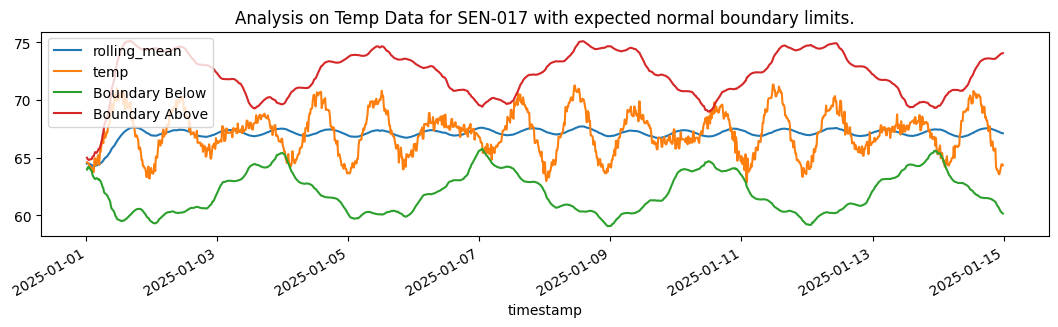

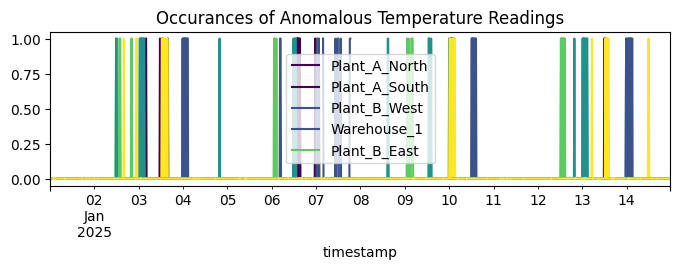

In [8]:
rolling_stats = (
    resampled_readings
    .groupby('sensor_id')
    .temp_c
    .rolling(window=96, min_periods=1)
    .agg(['mean','std'])
    .reset_index(level=0, drop=True)
)

rolling_stats = pd.merge(rolling_stats.reset_index(), sensor_dat, on='sensor_id') \
    .drop(columns=['install_date','Model','fw_ver']) \
    .set_index(['sensor_id','timestamp'])

rolling_stats['temp'] = resampled_readings.temp_c

rolling_stats = rolling_stats.dropna().rename(columns={'mean':'rolling_mean','std':'rolling_std'})

rolling_stats['Boundary Below'] = rolling_stats.rolling_mean - rolling_stats.rolling_std * 3
rolling_stats['Boundary Above'] = rolling_stats.rolling_mean + rolling_stats.rolling_std * 3

sensor = 'SEN-017'
rolling_stats.loc[sensor].drop(columns='rolling_std') \
    .plot(figsize=(13, 3),
          title=f'Analysis on Temp Data for {sensor} with expected normal boundary limits.')


rolling_stats['is_anomaly'] = rolling_stats.groupby('sensor_id') \
    .apply(lambda l: np.logical_or(l.temp < (l.rolling_mean - l.rolling_std * 3),l.temp > (l.rolling_mean + l.rolling_std * 3))) \
    .reset_index(level=0, drop=True).astype(int)

rolling_stats = rolling_stats.reset_index().set_index(['sensor_id','timestamp','Location'])

# rolling_stats.is_anomaly.unstack().transpose().plot(legend=False, title="Occurances of Anomalous Temperature Readings", figsize=(8,2))
# plt.show()


print('Anomalies are when a reading exceeds the the boundary of 3 STD above/below the Rolling 24hour Mean')
print('Anomalies are grouped together in 4 clusters that last about a day, clusters are not localized to region')
anomaly_matrix = rolling_stats.is_anomaly.unstack(level=1).transpose()
location_codes = anomaly_matrix.transpose().reset_index()['Location'].astype('category').cat.codes.values

cmap = plt.get_cmap('viridis')
colors = [cmap(i / ( len(np.unique(location_codes)) - 1)) for i in location_codes]

rolling_stats.is_anomaly.unstack(level=1).transpose() \
    .plot(title="Occurances of Anomalous Temperature Readings",
          figsize=(8,2),
          color=colors,
          label='Locations')
leg = plt.legend(rolling_stats.is_anomaly.unstack(level=1).transpose().columns.get_level_values(1).unique())
plt.show()




4. Sensor drift detection. Some sensors are slowly drifting out of calibration — their readings creep up or down over weeks even though the underlying physical reality is stable. Detect this by fitting a linear trend (slope) to each sensor's temperature over its full lifetime and flagging sensors whose slope exceeds a threshold (in degrees/day). Hint: numpy.polyfit or scipy.stats.linregress, applied per sensor.

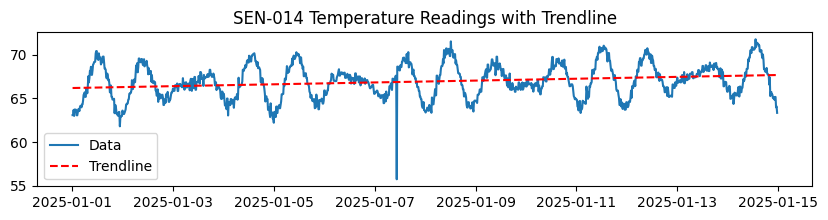

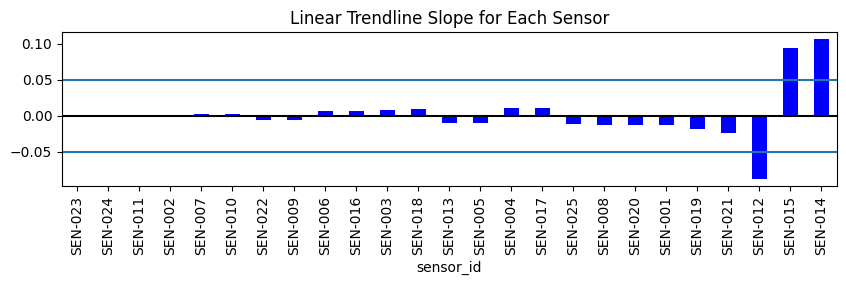

Sensors 12, 14, 15 are experiencing significant drift


In [9]:
import matplotlib.dates as mdates

sensor = 'SEN-014'
df = resampled_readings.loc[sensor].dropna()


x_num=mdates.date2num(df.index)
y = df.temp_c


slope, intercept = np.polyfit(x_num, y, 1)
p = np.poly1d((slope, intercept))
plt.figure(figsize=(10,2))
plt.plot(df.index, y, label='Data')
plt.plot(df.index, p(x_num), "r--", label='Trendline')
plt.title(f'{sensor} Temperature Readings with Trendline')

plt.legend()
plt.show()

def get_trend(group):
    slope, intercept = np.polyfit(group['x'], group['y'], 1)
    return pd.Series({'slope': slope, 'intercept': intercept})


plt.figure(figsize=(10,2))
trendlines = resampled_readings.dropna() \
    .groupby('sensor_id') \
    .apply(lambda l: get_trend({'x': mdates.date2num(l.reset_index().timestamp), 'y': l.temp_c.values}))

trendlines.sort_values('slope', key=abs).slope.plot.bar(color='blue', title='Linear Trendline Slope for Each Sensor')
plt.axhline(y=0.05)
plt.axhline(y=-0.05)
plt.axhline(y=0, color='black')
plt.show()

print('Sensors 12, 14, 15 are experiencing significant drift')


5. Correlated failures. Sensors in the same location should generally move together (shared environment). For each location, compute the pairwise correlation matrix of sensor temperatures (after resampling). Find pairs of sensors that should be correlated (same location) but aren't (correlation < 0.5) — these are candidates for being broken. Conversely, find any cross-location pairs with surprisingly high correlation.

Sensor SEN-021 at Warehouse_1 has the lowest crosswise correlation for sensors in a location and is likely broken


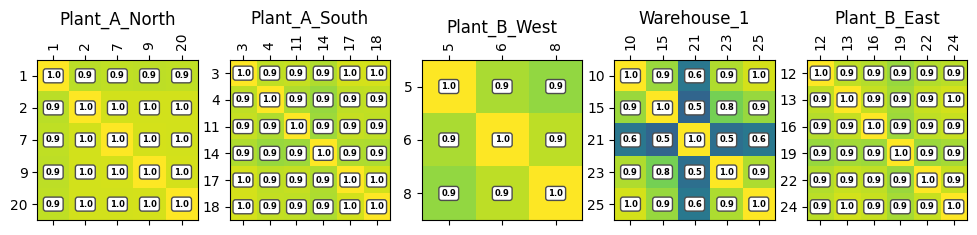

In [10]:
df = pd.merge(sensor_dat[['sensor_id','Location']], resampled_readings.reset_index(), on='sensor_id')

locations = df['Location'].unique()
df = df.set_index('Location')
fig, axes = plt.subplots(nrows=1, ncols=len(locations), figsize=(12, 4))

_vmin = df.pivot(index='timestamp', columns='sensor_id', values='temp_c').dropna().corr().min().min()
_vmax = df.pivot(index='timestamp', columns='sensor_id', values='temp_c').dropna().corr().max().max()
for col, ax in zip(locations, axes):
    corr = df.loc[col].pivot(index='timestamp', columns='sensor_id', values='temp_c').dropna().corr()
    # df.loc[col].groupby('sensor_id').temp_c.plot(ax=ax)
    ax.matshow(corr, vmin=_vmin, vmax=_vmax)
    ax.set_title(col)
    ax.set_xticks(ticks=range(len(corr.columns)), labels=[int(j[4:]) for j in corr.columns], rotation='vertical')
    ax.set_yticks(ticks=range(len(corr.columns)), labels=[int(j[4:]) for j in corr.columns], rotation='horizontal')
    for (i, j), z in np.ndenumerate(corr):
        ax.text(j, i, '{:0.1f}'.format(z), ha='center', va='center', fontsize=6, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.3'))
 


print('Sensor SEN-021 at Warehouse_1 has the lowest crosswise correlation for sensors in a location and is likely broken')

6. Stretch: cascading failure detection. The data contains at least one "cascading failure" — one sensor goes into error status, then within 2 hours, other sensors in the same location follow. Identify these events: find the first error in each location-time-cluster, then check whether other sensors in that location entered error status within the next 2 hours. Output a table of cascade events with the originating sensor, location, time, and the count of follow-on failures.

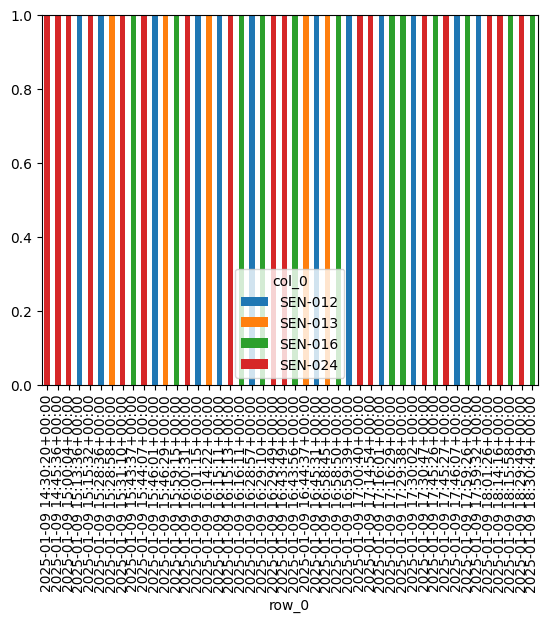

In [11]:
df = readings_dat.sort_values('timestamp').copy()
df['reading_id'] =  range(0, df.shape[0])
df.set_index('reading_id', inplace=True)

error_indicies = df.loc[df.status=='error'].index
anchor = df.iloc[error_indicies[0]]

df = df \
    [['sensor_id','timestamp','location','status']] \
    .query(f"location == '{anchor.location}' and status == 'error'") \
    .set_index('timestamp').sensor_id #.resample('15min').ffill()

ct = pd.crosstab(df.index, df.values)

fig, ax = plt.subplots()

ct.plot(kind='bar', ax=ax, stacked=True)
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%H-%M"))





# print('Sensor 24 threw an error on 1/9 14:00')

In [ ]:
# plt.figure(figsize=(10,2))

# df = readings_dat \
#     .iloc[anchor.name:] \
#     .loc[readings_dat.location == anchor.location] \
#     .loc[lambda x: x.status == 'error'][['sensor_id','timestamp']] \
#     .sort_values('timestamp') \
#     .set_index('timestamp') \
#     # .resample('15min').last()